# Lab 4: Data Visualization with Matplotlib & Seaborn

Welcome to Lab 4! So far you have learned to load, clean, and prepare data. But before you model anything, you need to *see* it. Numbers in a table rarely reveal patterns, outliers, or relationships on their own — visualizing the data is what makes them visible. This lab walks through creating and interpreting charts using Matplotlib and Seaborn, and introduces how visualization fits into Exploratory Data Analysis (EDA).

**After this lab you will be able to:**
- Create common Matplotlib plots (histograms, bar charts)
- Create statistical visualizations using Seaborn (count plots, box plots)
- Use a correlation heatmap to explore relationships between variables (EDA)
- Draw basic insights directly from a chart

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## Why Data Visualization Matters

A dataset's distribution, outliers, and the relationships between its variables are often invisible in a plain table but become clear almost immediately once visualized. This is why visualization is one of the very first steps in any real-world data or ML project.

The chart types you will use most often are:

- **Histograms** — show the distribution of a single numeric variable (e.g., how ages are spread out).
- **Bar / Count plots** — show the frequency of categories (e.g., how many passengers were in each class).
- **Box plots** — show the spread of a numeric variable across groups, and flag outliers.
- **Heatmaps** — show how strongly numeric variables are related to one another.

We will create each of these, one at a time, using the dataset below.

## Loading the Dataset

For this lab, we will use the well-known **Titanic dataset**, which contains information about passengers aboard the Titanic (age, sex, passenger class, fare, survival status, and more). It has a good mix of numeric and categorical columns, which makes it ideal for practicing visualization.

The dataset is loaded directly from a public link below — no manual download is needed.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()   # click the button that appears and select titanic.csv

df = pd.read_csv("titanic.csv")
df.head(10)

Saving titanic.csv to titanic (1).csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Step 1 — Inspecting the Data

Before choosing which chart to use, you need to know whether a column is numeric or categorical — this determines which plot type actually makes sense for it.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Exercise:** Using `df.select_dtypes()`, store the list of numeric column names in `numeric_cols`, and the list of categorical (object-type) column names in `categorical_cols`.

In [6]:
### YOUR CODE HERE ###
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
### END ###

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


**Expected Output (order may vary):**
```
Numeric columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
```

## Step 2 — Matplotlib: Histogram

A histogram shows how a numeric column's values are distributed across a range.

**Exercise:** Using `plt.hist()`, plot a histogram of the `Age` column (drop missing values first using `.dropna()`). Use 20 bins, and add a title, x-label ("Age"), and y-label ("Frequency").

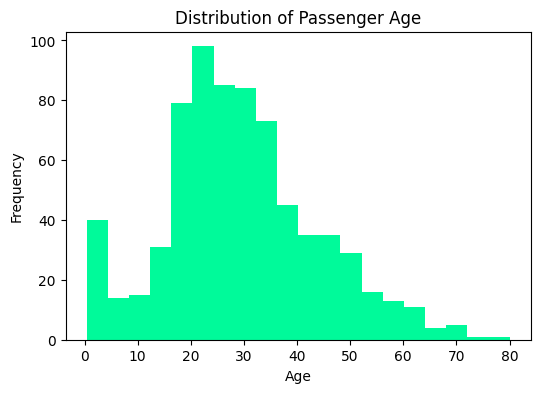

In [7]:
### YOUR CODE HERE ###
plt.figure(figsize=(6, 4))
plt.hist(df['Age'].dropna(), bins=20, color='mediumspringgreen')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
### END ###

plt.show()

## Step 3 — Matplotlib: Bar Chart

**Exercise:** Create a bar chart showing how many passengers were in each passenger class (`Pclass`).

- Hint: use `df['Pclass'].value_counts()` to get the counts, then plot them with `plt.bar()`
- Add a title and axis labels

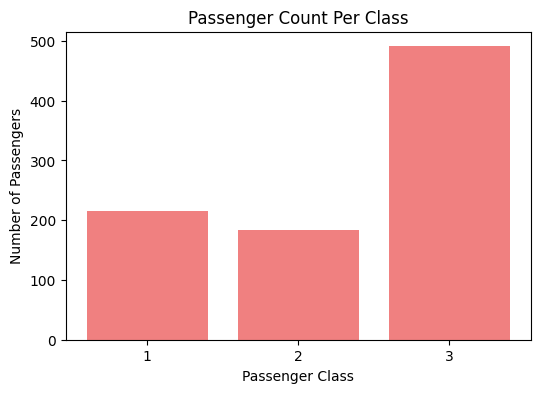

In [9]:
### YOUR CODE HERE ###
passengers_per_class = df['Pclass'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(passengers_per_class.index.astype(str), passengers_per_class.values, color='lightcoral')
plt.title('Passenger Count Per Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
### END ###

plt.show()

## Step 4 — Seaborn: Count Plot

Seaborn is built on top of Matplotlib and is designed specifically for statistical visualization — it usually needs less code and works directly with a DataFrame. The example below recreates the Step 3 chart using `sns.countplot()`. Run it and compare how much shorter the code is.

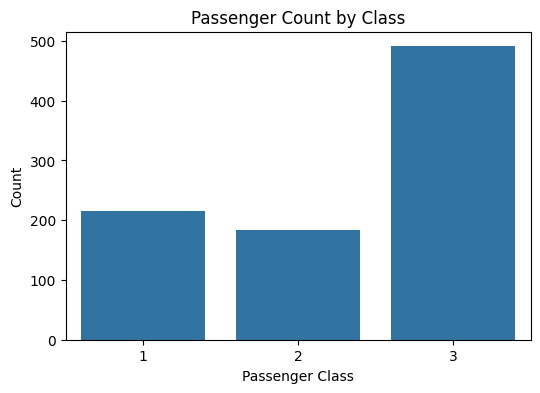

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Count by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

## Step 5 — Seaborn: Box Plot

A box plot shows the spread of a numeric variable across different groups, and makes outliers immediately visible as individual points beyond the whiskers.

**Exercise:** Create a box plot showing the `Fare` distribution across the three passenger classes (`Pclass`), using `sns.boxplot(x='Pclass', y='Fare', data=df)`.

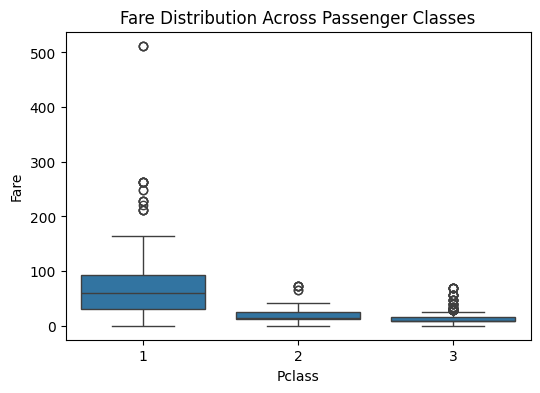

In [11]:
### YOUR CODE HERE ###
plt.figure(figsize=(6, 4))
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare Distribution Across Passenger Classes')
### END ###

plt.show()

## Step 6 — EDA: Correlation Heatmap

**Exploratory Data Analysis (EDA)** is the process of examining a dataset before modeling it, in order to understand its structure and spot patterns. A correlation heatmap is one of the most common EDA tools — it instantly reveals which numeric variables move together, something that is difficult to notice from raw numbers alone.

**Exercise:** Using `df.corr(numeric_only=True)` together with `sns.heatmap()`, create a correlation heatmap of the numeric columns. Set `annot=True` so the correlation values are visible on the chart.

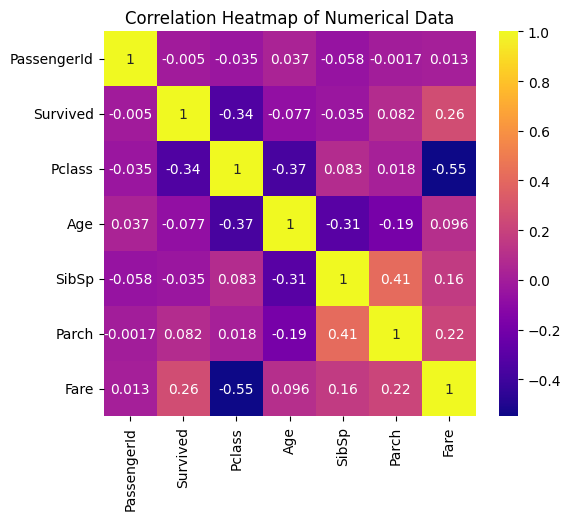

In [12]:
### YOUR CODE HERE ###
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='plasma')
plt.title('Correlation Heatmap of Numerical Data')
### END ###

plt.show()

**What to remember from this lab:**
- Check whether a column is numeric or categorical before choosing a chart type
- Histograms show distribution; bar/count plots show frequency; box plots show spread and outliers; heatmaps show relationships
- Seaborn is built on Matplotlib and usually needs less code for the same result
- A correlation heatmap is one of the most common tools used during EDA

## Lab Tasks

Complete the following tasks in this notebook, below this cell, using `df`.

1. **Full Visualization Recap:** In a markdown cell, write 3–4 sentences summarizing, in your own words, which chart types you used in this lab and what each one is best suited for.
2. **Age Distribution by Survival:** Create a plot (histogram or box plot) comparing the `Age` distribution between passengers who survived (`Survived == 1`) and those who did not (`Survived == 0`).
3. **Exploring Relationships:** Create a scatter plot of `Age` (x-axis) vs. `Fare` (y-axis), with points colored by `Survived` (hint: `sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)`).
4. **Survival Summary:** Using `df`, compute the average `Survived` rate and passenger count per `Pclass` and `Sex`, in a single `.groupby().agg()` call.
5. **Reflection:** In a markdown cell, note which chart in this lab you found most useful for revealing a pattern, and why.

In [ ]:
# Task 1 (markdown summary can go in a text cell below, or as a comment here)


In this lab, I used both Matplotlib and Seaborn to visualize the Titanic dataset. I created a histogram using Matplotlib to understand and visualize the distribution of passenger ages. I also generated a bar chart to display the number of passengers in each class. With Seaborn, I created a box plot to compare the fare distribution across distinct passenger classes and a correlation heatmap to represent and analyze relationships between numerical variables. These visualizations helped me identify patterns more efficiently, such as the relationship between class and fare, and the distribution of age among passengers.

/tmp/ipykernel_781/800973367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette=['red', 'springgreen'])


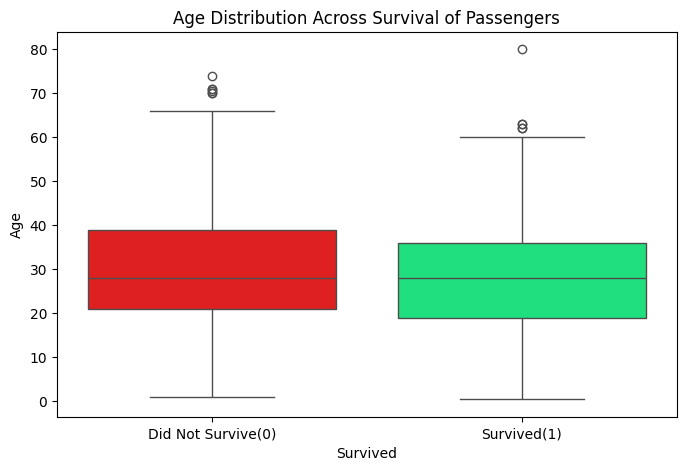

In [14]:
# Task 2
plt.figure(figsize=(8, 5))
sns.boxplot(x='Survived', y='Age', data=df, palette=['red', 'springgreen'])
plt.title('Age Distribution Across Survival of Passengers')
plt.xticks([0, 1], ['Did Not Survive(0)', 'Survived(1)'])

plt.show()


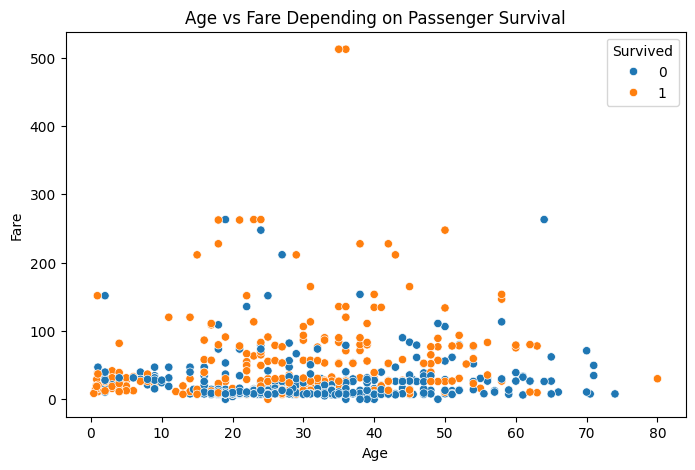

In [15]:
# Task 3
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Age vs Fare Depending on Passenger Survival')

plt.show()

In [17]:
# Task 4
survival_summary = df.groupby(['Pclass', 'Sex']).agg(
    Average_Survival_Rate = ('Survived', 'mean'),
    Passenger_Count = ('Survived', 'count')
).round(2)

print(survival_summary)

               Average_Survival_Rate  Passenger_Count
Pclass Sex                                           
1      female                   0.97               94
       male                     0.37              122
2      female                   0.92               76
       male                     0.16              108
3      female                   0.50              144
       male                     0.14              347


_Write your Task 5 reflection here._

The chart I found most useful was the **correlation heatmap** because it helped me quickly understand the relationships between distinct numerical variables in the dataset. For instance, it clearly showed that `Pclass` had a negative correlation with `Survived` and `Fare`, which made sense since higher-class passengers had a better chance of survival and paid greater fares. This visualization earned me valuable insights much faster than analyzing raw numbers or individual plots.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 24 (delta 6), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 58.56 KiB | 14.64 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Lab4_NumairFahad.ipynb" "/content/AIML-Internship-NumairFahad/"